In [1]:
import pandas as pd
import numpy as np

print("Python is working!")

Python is working!


In [2]:
import pandas as pd

df = pd.read_csv("Dataset/Dataset.csv")

df.head()

FileNotFoundError: [Errno 2] No such file or directory: 'Dataset/Dataset.csv'

In [ ]:
df.shape


(8790, 10)

In [ ]:
df.columns


Index(['show_id', 'type', 'title', 'director', 'country', 'date_added',
       'release_year', 'rating', 'duration', 'listed_in'],
      dtype='object')

In [ ]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8790 entries, 0 to 8789
Data columns (total 10 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       8790 non-null   object
 1   type          8790 non-null   object
 2   title         8790 non-null   object
 3   director      8790 non-null   object
 4   country       8790 non-null   object
 5   date_added    8790 non-null   object
 6   release_year  8790 non-null   int64 
 7   rating        8790 non-null   object
 8   duration      8790 non-null   object
 9   listed_in     8790 non-null   object
dtypes: int64(1), object(9)
memory usage: 686.8+ KB


In [ ]:
df.duplicated().sum()


np.int64(0)

In [ ]:
df.isnull().sum()


show_id         0
type            0
title           0
director        0
country         0
date_added      0
release_year    0
rating          0
duration        0
listed_in       0
dtype: int64

In [ ]:
df.describe()

,release_year
count,8790.000000
mean,2014.183163
std,8.825466
min,1925.000000
25%,2013.000000
50%,2017.000000
75%,2019.000000
max,2021.000000


In [ ]:
df["type"].value_counts()

type
Movie      6126
TV Show    2664
Name: count, dtype: int64

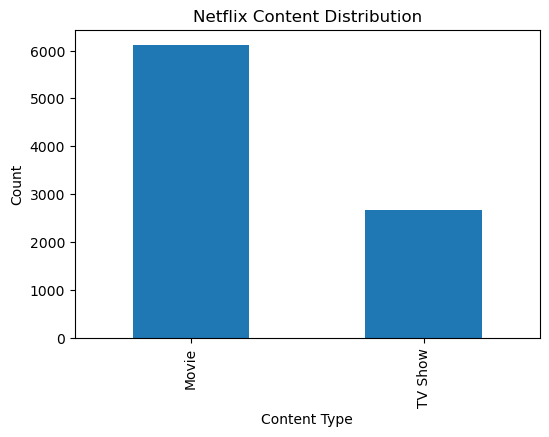

In [ ]:
import matplotlib.pyplot as plt

# Count Movies and TV Shows
content_type = df["type"].value_counts()

# Create Bar Chart
plt.figure(figsize=(6,4))
content_type.plot(kind="bar")

plt.title("Netflix Content Distribution")
plt.xlabel("Content Type")
plt.ylabel("Count")

plt.show()

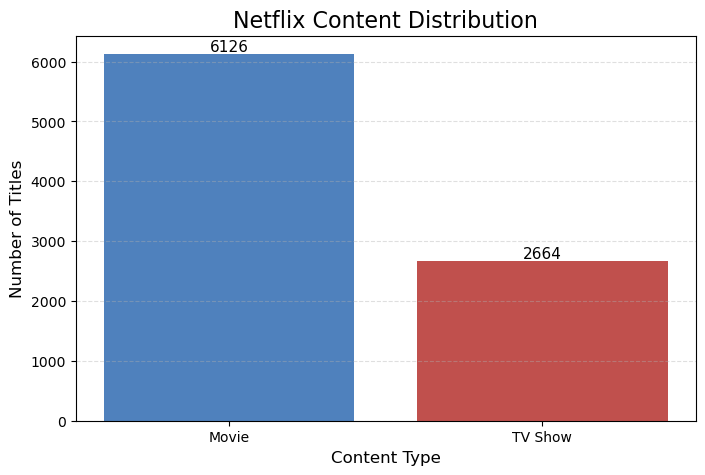

In [ ]:
import matplotlib.pyplot as plt

# Count Movies and TV Shows
content_type = df["type"].value_counts()

# Create Bar Chart
plt.figure(figsize=(8,5))

bars = plt.bar(content_type.index, content_type.values,
               color=["#4F81BD", "#C0504D"])

plt.title("Netflix Content Distribution", fontsize=16)
plt.xlabel("Content Type", fontsize=12)
plt.ylabel("Number of Titles", fontsize=12)

# Add values above bars
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2,
             height + 50,
             str(int(height)),
             ha='center',
             fontsize=11)

plt.grid(axis="y", linestyle="--", alpha=0.4)

plt.show()

## Dataset Overview

The Netflix dataset contains 8,790 records and 10 columns. The dataset includes information such as title, type, director, country, release year, rating, duration, and category. Initial exploration showed no missing values or duplicate records, making it suitable for further analysis.

## Business Insight

The analysis shows that Netflix's content library contains significantly more Movies (6,126) than TV Shows (2,664).

This indicates that Netflix has historically invested more heavily in movies than television series. The larger movie catalog provides users with a wider variety of films across different genres and languages.

# Task 1: Netflix Data Cleaning & Preparation

## Objective
The objective of this task is to explore and understand the Netflix dataset by examining its structure, checking for missing values and duplicate records, and creating an initial visualization of content distribution.

## Content Distribution Analysis

The following bar chart compares the number of Movies and TV Shows available in the Netflix dataset.

In [ ]:
release_year = df["release_year"].value_counts().sort_index()

release_year.head()

release_year
1925    1
1942    2
1943    3
1944    3
1945    4
Name: count, dtype: int64

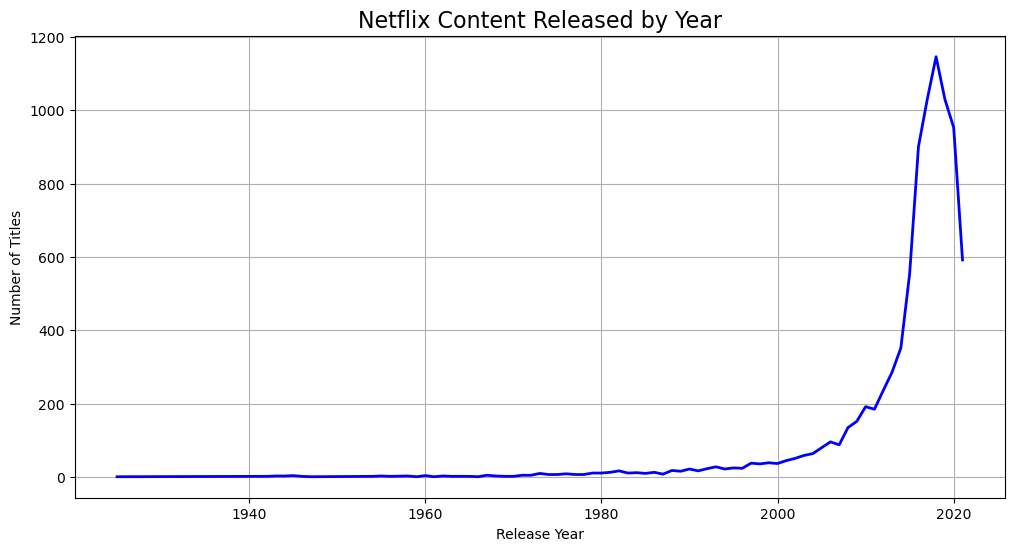

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))

plt.plot(release_year.index,
         release_year.values,
         color="blue",
         linewidth=2)

plt.title("Netflix Content Released by Year", fontsize=16)
plt.xlabel("Release Year")
plt.ylabel("Number of Titles")

plt.grid(True)

plt.show()

## Business Insight

The number of Netflix titles increased significantly after 2015, indicating rapid expansion of the platform's content library. The highest concentration of releases is observed in recent years, reflecting Netflix's increased investment in producing and acquiring new content.

## Business Insight

The analysis shows that Netflix significantly expanded its content library after 2015. The highest number of titles was released around 2019, indicating a major investment in original and licensed content. A decline after 2020 is observed, which may be influenced by production disruptions and the dataset covering only up to 2021.

In [ ]:
top_country = df["country"].value_counts().head(10)

top_country

country
United States     3240
India             1057
United Kingdom     638
Pakistan           421
Not Given          287
Canada             271
Japan              259
South Korea        214
France             213
Spain              182
Name: count, dtype: int64

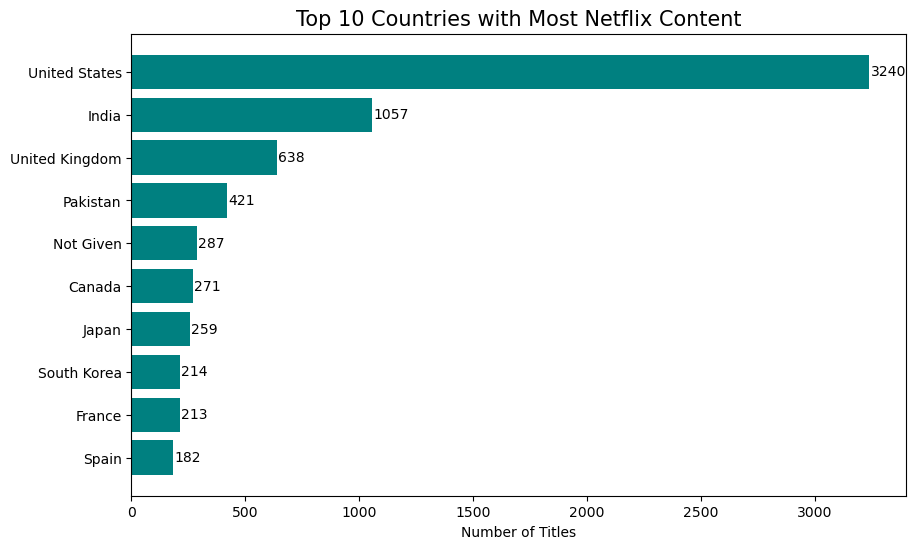

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

bars = plt.barh(top_country.index,
                top_country.values,
                color="teal")

plt.title("Top 10 Countries with Most Netflix Content", fontsize=15)

plt.xlabel("Number of Titles")

# Add values
for bar in bars:
    plt.text(bar.get_width()+5,
             bar.get_y()+bar.get_height()/2,
             str(int(bar.get_width())),
             va='center')

plt.gca().invert_yaxis()

plt.show()

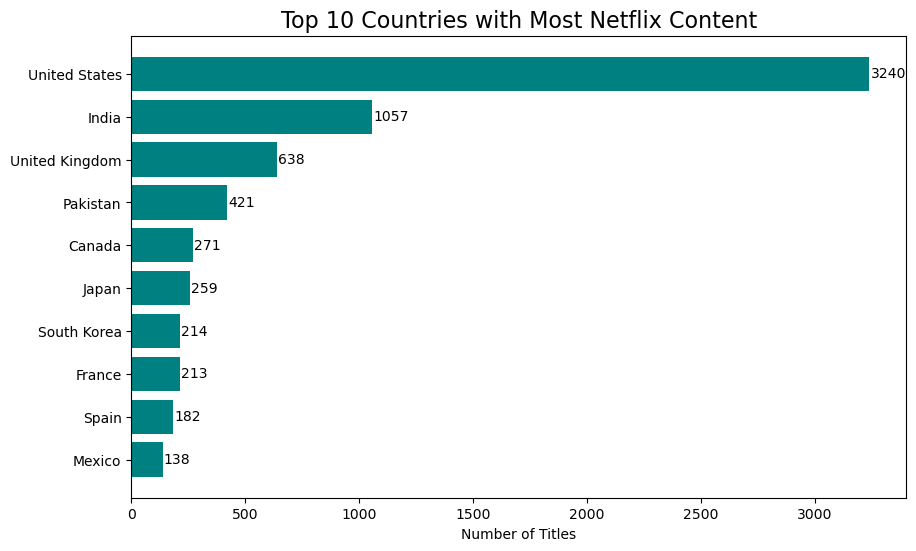

In [ ]:
# Remove "Not Given"
country_data = df[df["country"] != "Not Given"]

top_country = country_data["country"].value_counts().head(10)

plt.figure(figsize=(10,6))

bars = plt.barh(top_country.index,
                top_country.values,
                color="teal")

plt.title("Top 10 Countries with Most Netflix Content", fontsize=16)
plt.xlabel("Number of Titles")

for bar in bars:
    plt.text(bar.get_width()+5,
             bar.get_y()+bar.get_height()/2,
             int(bar.get_width()),
             va='center')

plt.gca().invert_yaxis()

plt.show()

## Business Insight

The United States has the largest number of Netflix titles with 3,240 entries, followed by India with 1,057 titles. This indicates that Netflix has a strong content presence in the United States while also investing significantly in Indian content. The presence of countries such as Japan, South Korea, France, and Spain highlights Netflix's growing focus on international and regional content.

In [ ]:
rating = df["rating"].value_counts()

rating

rating
TV-MA       3205
TV-14       2157
TV-PG        861
R            799
PG-13        490
TV-Y7        333
TV-Y         306
PG           287
TV-G         220
NR            79
G             41
TV-Y7-FV       6
NC-17          3
UR             3
Name: count, dtype: int64

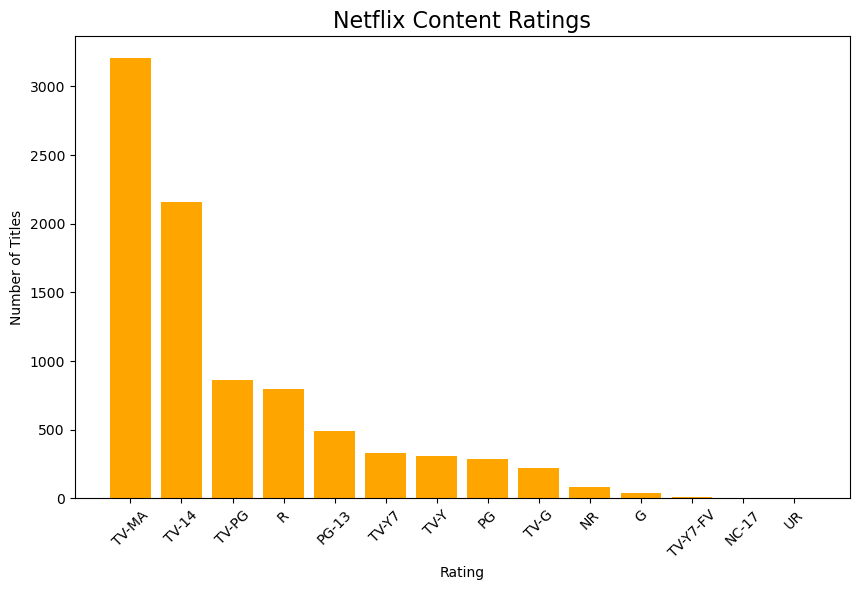

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

bars = plt.bar(rating.index,
               rating.values,
               color="orange")

plt.title("Netflix Content Ratings", fontsize=16)
plt.xlabel("Rating")
plt.ylabel("Number of Titles")

plt.xticks(rotation=45)

plt.show()

In [ ]:
rating = df["rating"].value_counts()

rating

rating
TV-MA       3205
TV-14       2157
TV-PG        861
R            799
PG-13        490
TV-Y7        333
TV-Y         306
PG           287
TV-G         220
NR            79
G             41
TV-Y7-FV       6
NC-17          3
UR             3
Name: count, dtype: int64

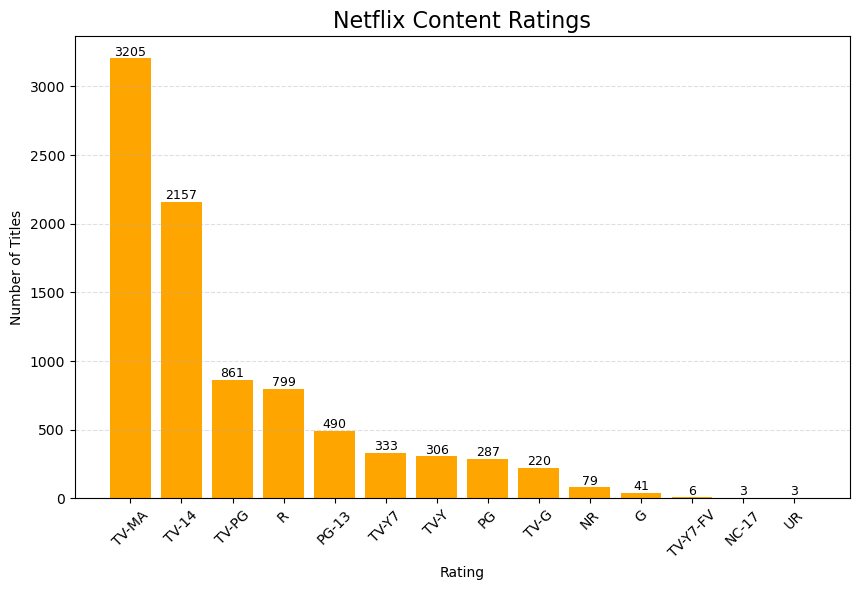

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

bars = plt.bar(
    rating.index,
    rating.values,
    color="orange"
)

plt.title("Netflix Content Ratings", fontsize=16)
plt.xlabel("Rating")
plt.ylabel("Number of Titles")

plt.xticks(rotation=45)

# Display values above bars
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height + 20,
        str(int(height)),
        ha='center',
        fontsize=9
    )

plt.grid(axis="y", linestyle="--", alpha=0.4)

plt.show()

## Business Insight

The analysis of Netflix content ratings shows that TV-MA and TV-14 account for the largest share of titles. This indicates that Netflix primarily targets mature and teenage audiences while still offering content suitable for families and children through ratings such as PG, TV-PG, and G.

In [ ]:
df["listed_in"].head()

0                                        Documentaries
1    Crime TV Shows, International TV Shows, TV Act...
2                   TV Dramas, TV Horror, TV Mysteries
3                   Children & Family Movies, Comedies
4     Dramas, Independent Movies, International Movies
Name: listed_in, dtype: object

In [ ]:
genre = (
    df["listed_in"]
    .str.split(", ")
    .explode()
)

genre.head()

0             Documentaries
1            Crime TV Shows
1    International TV Shows
1     TV Action & Adventure
2                 TV Dramas
Name: listed_in, dtype: object

In [ ]:
top_genres = genre.value_counts().head(10)

top_genres

listed_in
International Movies        2752
Dramas                      2426
Comedies                    1674
International TV Shows      1349
Documentaries                869
Action & Adventure           859
TV Dramas                    762
Independent Movies           756
Children & Family Movies     641
Romantic Movies              616
Name: count, dtype: int64

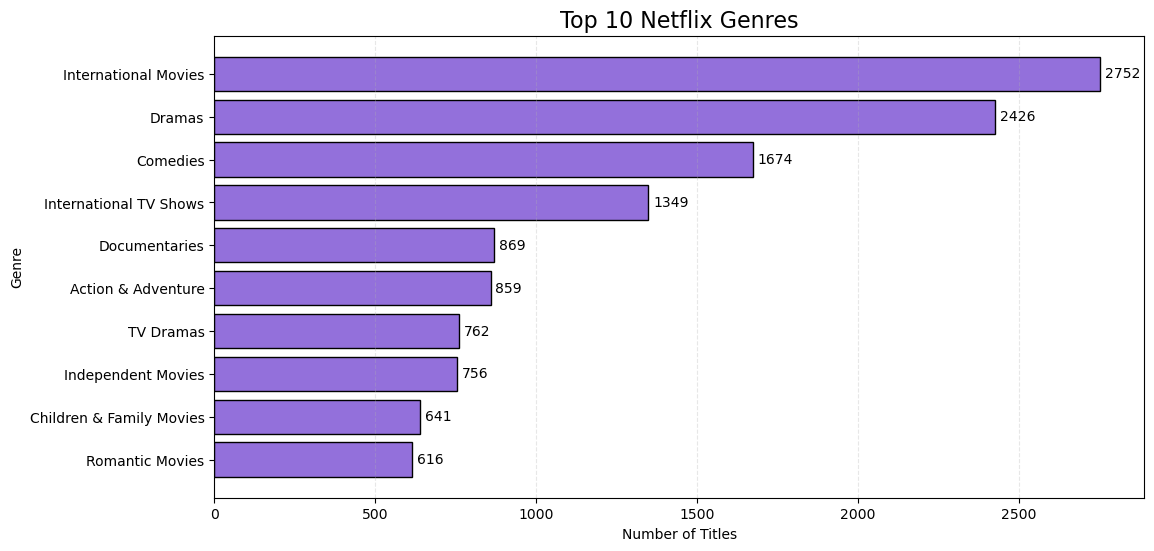

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))

bars = plt.barh(
    top_genres.index,
    top_genres.values,
    color="mediumpurple",
    edgecolor="black"
)

plt.title("Top 10 Netflix Genres", fontsize=16)
plt.xlabel("Number of Titles")
plt.ylabel("Genre")

# Add values
for bar in bars:
    plt.text(
        bar.get_width()+15,
        bar.get_y()+bar.get_height()/2,
        str(int(bar.get_width())),
        va="center",
        fontsize=10
    )

plt.gca().invert_yaxis()

plt.grid(axis="x", linestyle="--", alpha=0.3)

plt.show()

## Business Insight

The analysis shows that International Movies, Dramas, and Comedies are among the most common genres on Netflix. This indicates that Netflix focuses on delivering diverse entertainment to a global audience while maintaining a strong catalog of drama and comedy content.

## Business Insight

The genre analysis shows that **International Movies** is the largest genre on Netflix with **2,752 titles**, followed by **Dramas** and **Comedies**.

This suggests that Netflix focuses heavily on providing content for a global audience while maintaining a strong collection of drama and comedy titles. The presence of documentaries, action & adventure, and family movies also reflects a diverse content strategy designed to appeal to different viewer preferences.

In [ ]:
df.to_csv("Cleaned_Data/Netflix_Cleaned.csv", index=False)

print("Cleaned dataset saved successfully!")

Cleaned dataset saved successfully!


# Project Summary

## Objective
The objective of this project was to explore and analyze the Netflix dataset using Python and Pandas.

## Dataset
- Records: 8,790
- Columns: 10

## Data Cleaning
- Checked for missing values
- Checked for duplicate records
- Verified data types

## Analysis Performed
- Content Distribution
- Release Year Trend
- Top Countries
- Content Ratings
- Genre Analysis

## Key Findings
- Movies outnumber TV Shows.
- Netflix content increased significantly after 2015.
- The United States has the highest number of titles.
- TV-MA is the most common content rating.
- International Movies is the most common genre.

## Conclusion
The Netflix dataset shows that the platform has expanded rapidly in recent years while maintaining a diverse global catalog across multiple genres and audience categories.